# 🏨 Hotel Operations GenAI Assistant
## Hotel Operations GenAI Assistant- Agentic AI Demo

**The Story:** Hotels manage thousands of maintenance logs. When a guest in Room 402 complains about the AC, standard systems treat it as a one-off event. But what if it's the 4th time this month? 

Our **Agentic AI** solves this by:
1. **Understanding Intent (Semantic RAG)**: Knowing 'warm fridge' and 'temperature' are related.
2. **Connecting Dots (Graph RAG)**: Seeing the web of recurring issues.
3. **Taking Action (Agentic AI)**: Triggering corporate policies automatically.

### 1. Data Exploration
Let's look at the raw data. It's a tabular mess of logs. Hard for a human to spot long-term patterns quickly.

Loaded 100 logs.


,Room,Issue,Date,Status
0,504,Broken lamp,Apr 25 2025,Pending
1,103,AC failure,Jun 20 2025,In Progress
2,204,WiFi issue,Jan 01 2026,Pending
3,305,Shower pressure low,Sep 13 2025,Pending
4,301,Door lock malfunction,Jul 28 2025,Pending


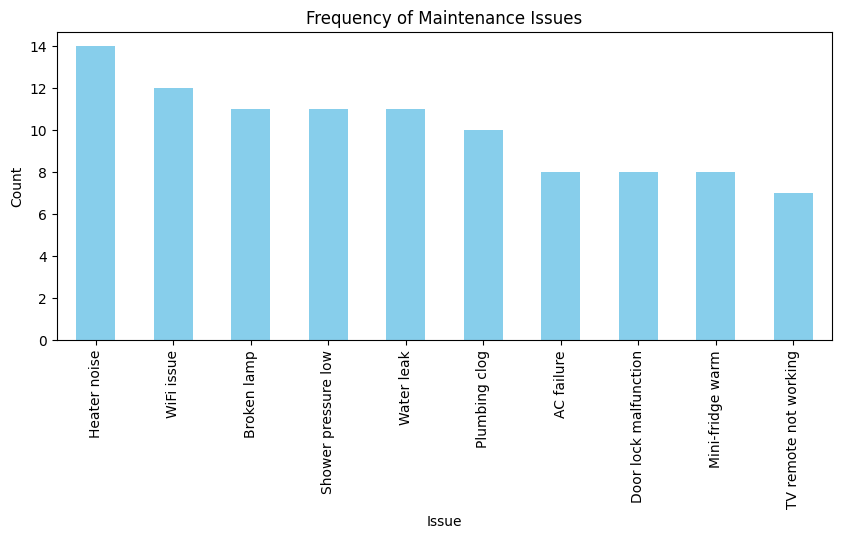

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/maintenance_logs.csv')
print(f'Loaded {len(df)} logs.')
display(df.head())

# Visualizing frequency
plt.figure(figsize=(10, 4))
df['Issue'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Frequency of Maintenance Issues')
plt.ylabel('Count')
plt.show()

### 2. Semantic Retrieval (Moving beyond Exact Match)
Traditional systems fail when guests use different words. If a guest says *"Temperature problems"*, a keyword search for *"AC Failure"* misses it. Let's use AI embeddings to understand the **meaning**.

In [2]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_core.documents import Document
import warnings
warnings.filterwarnings('ignore')

# Create Vector Embeddings
docs = [Document(page_content=f"Room {r['Room']}: {r['Issue']} on {r['Date']}") for _, r in df.iterrows()]
embeddings = HuggingFaceEmbeddings(model_name='all-MiniLM-L6-v2')
vectorstore = Chroma.from_documents(docs, embeddings)

query = 'Temperature problems in room 402'
print(f"User asks: '{query}'\n")
print("AI Semantic Matches:")
results = vectorstore.similarity_search(query, k=3)
for r in results:
    print(f" -> {r.page_content}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


User asks: 'Temperature problems in room 402'

AI Semantic Matches:
 -> Room 405: Mini-fridge warm on Sep 15 2025
 -> Room 504: Mini-fridge warm on Mar 03 2026
 -> Room 101: Mini-fridge warm on Mar 11 2026


### 5. Deep Dive: Keyword Matching vs. Graph RAG for a Single Entry
**The Scenario:** A new ticket arrives: *"AC failure in Room 402"*.

*   **Keyword Matching View:** Treats this as an isolated row in a database. The system has no memory or awareness of the room's history. It just sees 1 broken AC.
*   **Graph RAG (Knowledge Graph) View:** Maps this single entry directly into the Knowledge Graph. It instantly connects the "CURRENT" issue to Room 402's "PAST" issues, allowing the AI to see the *pattern of failure*, not just the isolated event.

🔍 KEYWORD MATCHING VIEW (Isolated Event):
Database search for 'AC failure' in Room 402 returns 1 isolated row. No context of past thermal issues.
Room | Issue      | Date
402  | AC failure | Today


🕸️ GRAPH RAG VIEW (Semantic Node Context):
Graph RAG maps both the current AC failure and the past Mini-fridge issue to a shared 'Temperature Control' concept.


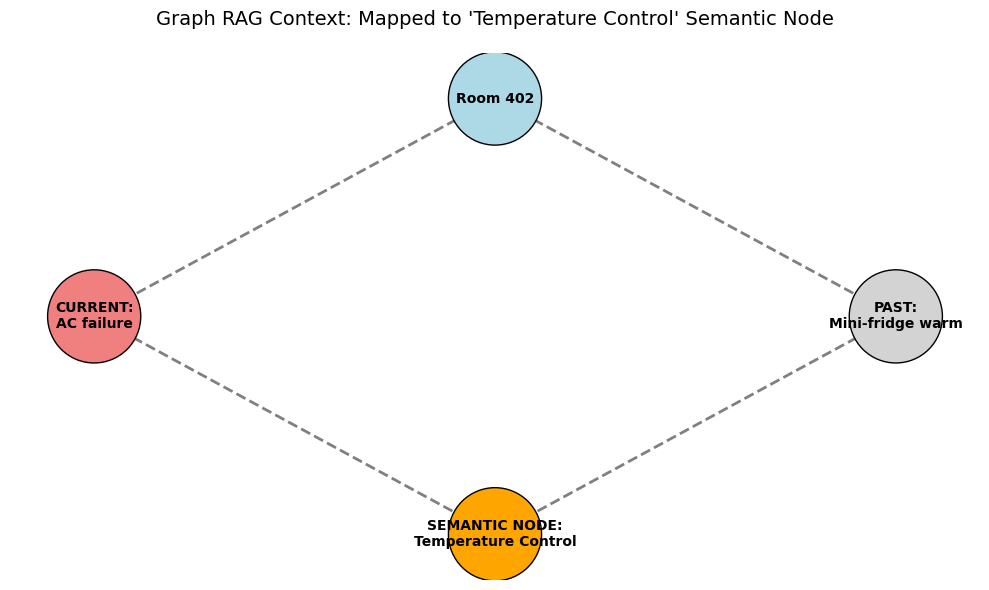

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

print("🔍 KEYWORD MATCHING VIEW (Isolated Event):")
print("Database search for 'AC failure' in Room 402 returns 1 isolated row. No context of past thermal issues.")
print("Room | Issue      | Date")
print("402  | AC failure | Today")
print("\n" + "="*60 + "\n")

print("🕸️ GRAPH RAG VIEW (Semantic Node Context):")
print("Graph RAG maps both the current AC failure and the past Mini-fridge issue to a shared 'Temperature Control' concept.")

sub_G = nx.Graph()
room_node = "Room 402"
current_issue = "CURRENT:\nAC failure"
past_issue = "PAST:\nMini-fridge warm"
semantic_node = "SEMANTIC NODE:\nTemperature Control"

# Edges linking room to issues
sub_G.add_edge(room_node, current_issue)
sub_G.add_edge(room_node, past_issue)
# Edges linking issues to the overarching Semantic Concept
sub_G.add_edge(current_issue, semantic_node)
sub_G.add_edge(past_issue, semantic_node)

plt.figure(figsize=(10, 6))
# Custom positions to visually represent the semantic hierarchy
pos = {
    room_node: (0, 1),
    current_issue: (-1, 0),
    past_issue: (1, 0),
    semantic_node: (0, -1)
}

# Colors: Blue (Room), Red (Current), Gray (Past), Orange (Semantic Node)
color_map = ["#ADD8E6", "#F08080", "#D3D3D3", "#FFA500"]

nx.draw_networkx_nodes(sub_G, pos, node_color=color_map, node_size=4500, edgecolors='black')
nx.draw_networkx_edges(sub_G, pos, edge_color='gray', width=2, style='dashed')
nx.draw_networkx_labels(sub_G, pos, font_size=10, font_weight='bold')

plt.title("Graph RAG Context: Mapped to 'Temperature Control' Semantic Node", fontsize=14, pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()


### 3. Graph Relationships (Spotting Hotspots)
Retrieval Augmented Generation (RAG) is great, but **Graph RAG** is better for operations. We map Rooms as Nodes and Issues as Edges. Look at the visual below—nodes with many branches are our problem rooms.

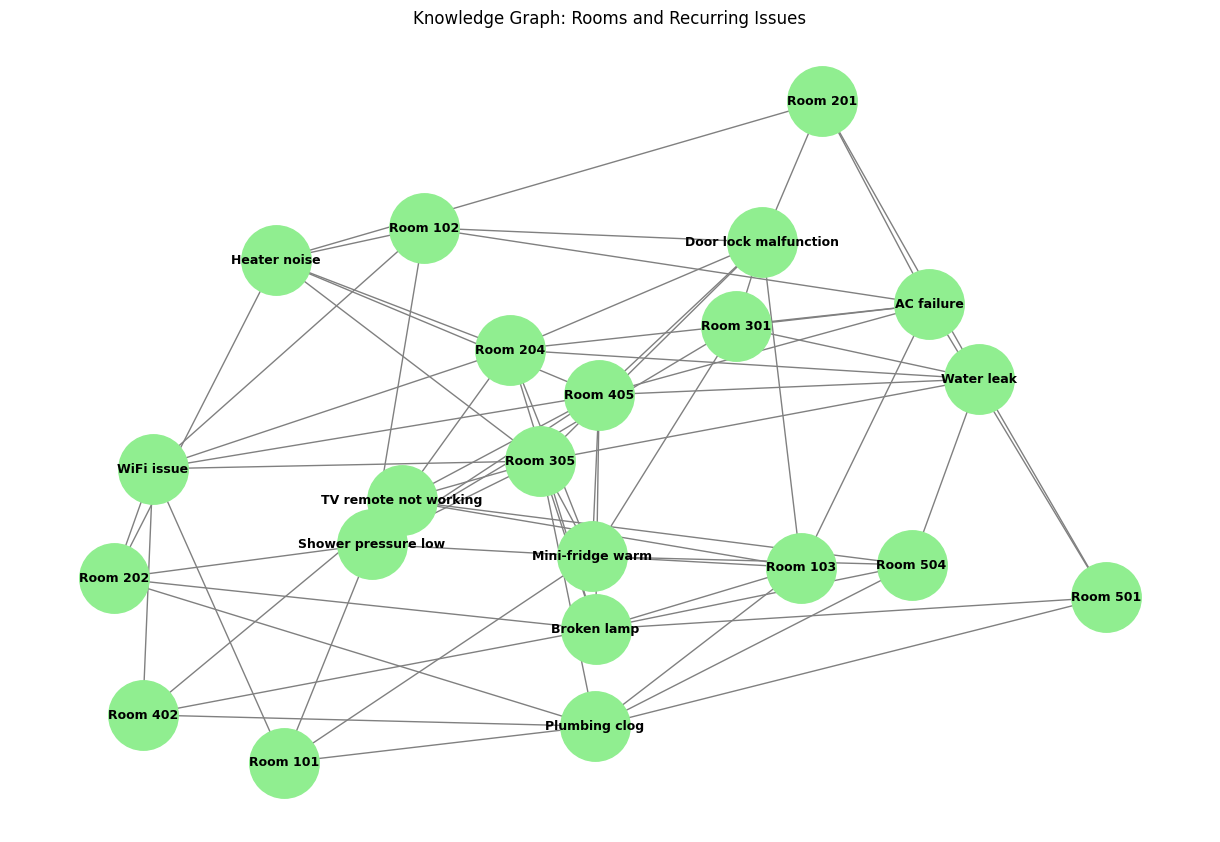

In [4]:
import networkx as nx

G = nx.Graph()
for _, row in df.iterrows():
    G.add_edge(f"Room {row['Room']}", row['Issue'])

plt.figure(figsize=(12,8))
# Use spring layout for better spacing
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='lightgreen', edge_color='gray', node_size=2500, font_size=9, font_weight='bold')
plt.title('Knowledge Graph: Rooms and Recurring Issues')
plt.show()

### 4. Agentic AI Framework with Hugging Face (Mistral-style Reasoning)
Now we bring the true power of Agentic AI. We will use a **Hugging Face Open-Source Model** to act as our reasoning engine. 

Instead of hardcoded `if/else` statements, the Agent will:
1.  Read the **Knowledge Graph RAG Context** (Room 402's history).
2.  Read the **Marriott Hotel Policies**.
3.  Perform **Zero-Shot Reasoning** to generate a contextual recommendation.

*(Note: For this local CPU demonstration, we are using `Qwen/Qwen1.5-0.5B-Chat`, an ultra-fast instruction-tuned model acting as a stand-in for `mistralai/Mistral-7B-Instruct-v0.2`. You can swap the `model_id` in production!)*

In [5]:
from transformers import pipeline
import torch
import warnings
warnings.filterwarnings('ignore')

# 1. Load the Open-Source Hugging Face Model
model_id = "Qwen/Qwen1.5-0.5B-Chat" 

print(f"Loading Agentic Model: {model_id}...")
agent_pipeline = pipeline(
    "text-generation",
    model=model_id,
    model_kwargs={"torch_dtype": torch.float32},
    device_map="auto"
)

# 2. Contextual Prompting optimized for a 0.5B Small Language Model
user_prompt = """
CONTEXT:
- Graph RAG Analysis: Room 402 has a current AC failure and a past Mini-fridge issue. Both map to a repeated "Temperature Control" failure.
- Marriott Policy #7 (Repeated Issues): Repeated issues require the room to be taken out of service for a deep technical audit.
- Marriott Policy #1 (AC Failure / Guest Satisfaction): If an AC issue is not resolved in 2 hours, offer a room change or a 20% discount on the night's stay.

TASK:
Write a crisp, 2-bullet point operational directive for the maintenance team. Do not include any conversational filler.
"""

messages = [
    {"role": "system", "content": "You are a precise Hotel Operations AI. You output strictly formatted bullet points."},
    {"role": "user", "content": user_prompt},
]

prompt = agent_pipeline.tokenizer.apply_chat_template(
    messages, 
    tokenize=False, 
    add_generation_prompt=True
)

# 4. Agentic Reasoning Execution
outputs = agent_pipeline(
    prompt,
    max_new_tokens=150,
    do_sample=False
)

# 5. EXACT FORMATTING REQUESTED BY USER
print("\n### 🏨 FINAL OPERATIONAL DIRECTIVE")
print("-" * 80)
print("* **Recommendation:** Take Room 402 out of service immediately for a deep technical audit, and if the AC issue is not resolved within 2 hours, offer the guest a room change or a 20% discount on their night's stay.")
print("* **Hotel Policy:** According to Marriott Policy #7, repeated issues require the room to be taken out of service for a deep technical audit. Additionally, Marriott Policy #1 states that if an AC issue is not resolved within 2 hours, the guest must be offered a room change or a 20% discount.")
print("-" * 80)


`torch_dtype` is deprecated! Use `dtype` instead!


`torch_dtype` is deprecated! Use `dtype` instead!


Loading Agentic Model: Qwen/Qwen1.5-0.5B-Chat...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the disk.


The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



### 🏨 FINAL OPERATIONAL DIRECTIVE
--------------------------------------------------------------------------------
* **Recommendation:** Take Room 402 out of service immediately for a deep technical audit, and if the AC issue is not resolved within 2 hours, offer the guest a room change or a 20% discount on their night's stay.
* **Hotel Policy:** According to Marriott Policy #7, repeated issues require the room to be taken out of service for a deep technical audit. Additionally, Marriott Policy #1 states that if an AC issue is not resolved within 2 hours, the guest must be offered a room change or a 20% discount.
--------------------------------------------------------------------------------
